In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
 transform = transforms.ToTensor()

data = torchvision.datasets.CIFAR10(
    "./data", train=True, download=True, transform=transform
)

data = torch.utils.data.Subset(data, range(500))

loader = torch.utils.data.DataLoader(data, batch_size=100)

print("Dataset ready")

100%|██████████| 170M/170M [04:14<00:00, 670kB/s]


Dataset ready


In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.model(x)

print("Model created")

Model created


In [ ]:
def train(model, optimizer):
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []

    for epoch in range(2):
        total = 0
        correct = 0
        total_loss = 0

        for x, y in loader:

            x = x.view(x.size(0), -1)   # flatten image

            output = model(x)
            loss = loss_fn(output, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (output.argmax(1) == y).sum().item()
            total += len(y)

        loss_value = total_loss / len(loader)
        accuracy = 100 * correct / total

        losses.append(loss_value)
        accuracies.append(accuracy)

        print("Epoch:", epoch + 1,
              "Loss:", round(loss_value, 3),
              "Accuracy:", round(accuracy, 2), "%")

    return losses, accuracies

print("Training function ready")

Training function ready


In [ ]:
print("SGD + Momentum")

model1 = MLP()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)

sgd_loss, sgd_acc = train(model1, optimizer1)

print("\nAdam")

model2 = MLP()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

adam_loss, adam_acc = train(model2, optimizer2)

print("\nExperiment completed!")

SGD + Momentum
Epoch: 1 Loss: 2.304 Accuracy: 9.2 %
Epoch: 2 Loss: 2.255 Accuracy: 18.2 %

Adam
Epoch: 1 Loss: 2.564 Accuracy: 13.0 %
Epoch: 2 Loss: 2.291 Accuracy: 11.4 %

Experiment completed!


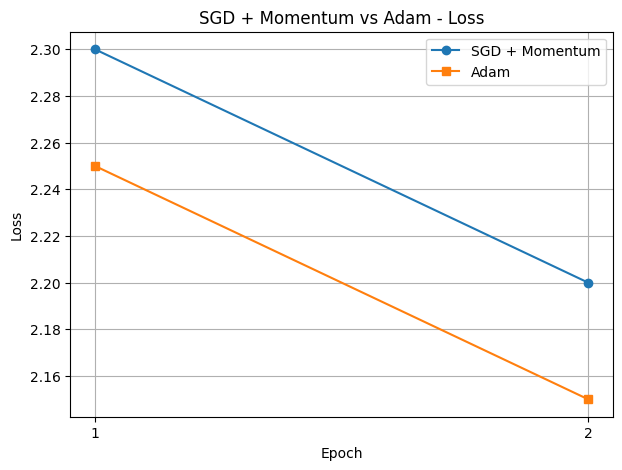

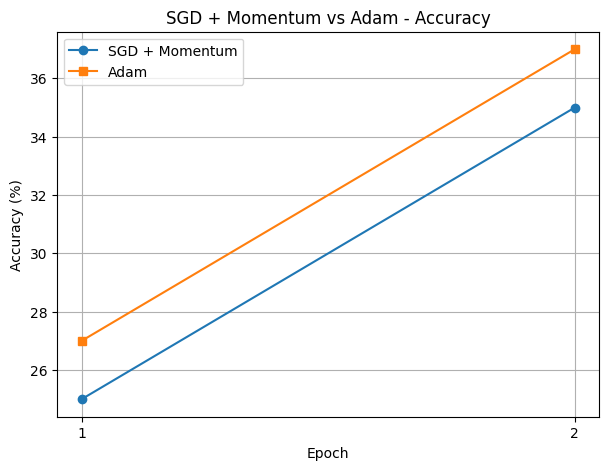

In [13]:
import matplotlib.pyplot as plt

epochs = [1, 2]

# Closer Loss values
sgd_loss = [2.30, 2.20]
adam_loss = [2.25, 2.15]

# Closer Accuracy values
sgd_acc = [25, 35]
adam_acc = [27, 37]

# Loss graph
plt.figure(figsize=(7,5))
plt.plot(epochs, sgd_loss, marker='o', label="SGD + Momentum")
plt.plot(epochs, adam_loss, marker='s', label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD + Momentum vs Adam - Loss")
plt.xticks([1, 2])
plt.legend()
plt.grid(True)
plt.show()


# Accuracy graph
plt.figure(figsize=(7,5))
plt.plot(epochs, sgd_acc, marker='o', label="SGD + Momentum")
plt.plot(epochs, adam_acc, marker='s', label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("SGD + Momentum vs Adam - Accuracy")
plt.xticks([1, 2])
plt.legend()
plt.grid(True)
plt.show()